In [26]:
# Set up cell for simulation

import datetime
import random
import numpy as np
import pandas as pd
import sys
import os
import subprocess

netlist_dir = "program-segments/netlists/"
sys.path.append(netlist_dir)

VHIGH = 1.5
threshold = 0.5
letter_bool_map = { "0": [False, False],
                    "1": [True, True],
                    "R": [False, True],
                    "F": [True, False]}
input_delays = [10.0, 20.0, 30.0]

log = open("ML.log", "a")
log.write(str(datetime.datetime.now()) + "\n")

log.write("Importing gate ...\n")
gate_name = "NAND"
input_num = 2
mod_name = gate_name+"-"+str(input_num)
gate = __import__(mod_name)
print(gate)
print(gate_name+"-"+str(input_num))


<module 'NAND-2' from 'program-segments/netlists/NAND-2.py'>
NAND-2


In [27]:
log.write("Reading in input event combinations for cell ...\n")

#if os.path.exists(netlist_dir+mod_name+".in") == False:
#    os.system("python3 make_inputs_slow.py "+gate_name+" "+str(input_num))

os.system("python3 make_inputs_slow.py "+gate_name+" "+str(input_num))

infile = open(netlist_dir+mod_name+".in", "r");
infile_lines = infile.readlines()
infile_arr = [inp.split(' ')[0:input_num] for inp in infile_lines]
infile.close()

input_transition_list = []

for i in range(0, len(infile_arr)):
    for delay in input_delays:
        input_transition = []
        for j in range(0, input_num):
            input_transition.append(infile_arr[i][j])
            input_transition.append(delay)
        input_transition_list.append(input_transition)        

for i in range(0, len(input_transition_list)):
    print(input_transition_list[i])
    
print("Done")
#for input_transition in input_transition_list:
#    print(input_transition[::2])

['1', 10.0, 'R', 10.0]
['1', 20.0, 'R', 20.0]
['1', 30.0, 'R', 30.0]
['1', 10.0, 'F', 10.0]
['1', 20.0, 'F', 20.0]
['1', 30.0, 'F', 30.0]
['R', 10.0, '1', 10.0]
['R', 20.0, '1', 20.0]
['R', 30.0, '1', 30.0]
['R', 10.0, 'R', 10.0]
['R', 20.0, 'R', 20.0]
['R', 30.0, 'R', 30.0]
['F', 10.0, '1', 10.0]
['F', 20.0, '1', 20.0]
['F', 30.0, '1', 30.0]
['F', 10.0, 'F', 10.0]
['F', 20.0, 'F', 20.0]
['F', 30.0, 'F', 30.0]
Done


In [4]:
log.write("Creating spice files for simulating all input event combinations ...\n")

for input_transitions in input_transition_list:
    command = "./mkspicefile " + gate_name + " " + str(input_num) + " "
    first_change = ""
    threshold_voltage_in = 0
    threshold_voltage_out = 0
    for inp in input_transitions[::2]:
        if inp == "R":
            threshold_voltage_in = threshold*VHIGH + (1 - threshold)*0
            threshold_voltage_in = round(threshold_voltage_in, 3)
            break
        if inp == "F":
            threshold_voltage_in = threshold*0 + (1 - threshold)*VHIGH
            threshold_voltage_in = round(threshold_voltage_in, 3)
            break
    bool_input_trans = [letter_bool_map[input_trans] for input_trans in input_transitions[::2]]
    #print(bool_input_trans)
    bool_output_trans = gate.transition(bool_input_trans)

    if bool_output_trans == letter_bool_map["R"]:
        threshold_voltage_out = threshold*VHIGH + (1 - threshold)*0
    elif bool_output_trans == letter_bool_map["F"]:
        threshold_voltage_out = threshold*0 + (1 - threshold)*VHIGH
    threshold_voltage_out = round(threshold_voltage_out, 3)

    command += str(threshold_voltage_in) + " " + str(threshold_voltage_out) + " "
    
    for i in range(0, input_num):
        command += input_transitions[2*i]+"_"
        command += str(input_transitions[2*i+1]/2)+" "
    print(command)
    os.system(command)


./mkspicefile NAND 2 0.75 0.75 1_5.0 R_5.0 
./mkspicefile NAND 2 0.75 0.75 1_10.0 R_10.0 
./mkspicefile NAND 2 0.75 0.75 1_15.0 R_15.0 
./mkspicefile NAND 2 0.75 0.75 1_5.0 F_5.0 
./mkspicefile NAND 2 0.75 0.75 1_10.0 F_10.0 
./mkspicefile NAND 2 0.75 0.75 1_15.0 F_15.0 
./mkspicefile NAND 2 0.75 0.75 R_5.0 1_5.0 
./mkspicefile NAND 2 0.75 0.75 R_10.0 1_10.0 
./mkspicefile NAND 2 0.75 0.75 R_15.0 1_15.0 
./mkspicefile NAND 2 0.75 0.75 R_5.0 R_5.0 
./mkspicefile NAND 2 0.75 0.75 R_10.0 R_10.0 
./mkspicefile NAND 2 0.75 0.75 R_15.0 R_15.0 
./mkspicefile NAND 2 0.75 0.75 F_5.0 1_5.0 
./mkspicefile NAND 2 0.75 0.75 F_10.0 1_10.0 
./mkspicefile NAND 2 0.75 0.75 F_15.0 1_15.0 
./mkspicefile NAND 2 0.75 0.75 F_5.0 F_5.0 
./mkspicefile NAND 2 0.75 0.75 F_10.0 F_10.0 
./mkspicefile NAND 2 0.75 0.75 F_15.0 F_15.0 


In [5]:
log.write("Running ngspice simulations with spice files ...\n")

for input_transitions in input_transition_list:
    fname = gate_name+"_"+str(input_num)+"__"
    for i in range(0, input_num):
        fname += input_transitions[2*i]+"_"+str(input_transitions[2*i+1]/2)+"-"
    fname = fname[0:-1]
    command = "ngspice -b simulation-programs/"+fname+".sp"
    print(command)
    spice_out = open("simulation-output/"+fname+".stdout", "w")
    spice_out.write(subprocess.getoutput(command))
    spice_out.close()
    
    # add runtime info to simulation-output/.out file
    grp_command = "grep 'elapsed' "+"simulation-output/"+fname+".stdout"
    print(grp_command)
    runtime_statement = subprocess.getoutput(grp_command)
    runtime = float(runtime_statement.split("=")[1])
    
    time_out = open("simulation-output/"+fname+".out", "a")
    time_out.write("Runtime: "+str(runtime)+"\n")
    time_out.close()

ngspice -b simulation-programs/NAND_2__1_5.0-R_5.0.sp
grep 'elapsed' simulation-output/NAND_2__1_5.0-R_5.0.stdout
ngspice -b simulation-programs/NAND_2__1_10.0-R_10.0.sp
grep 'elapsed' simulation-output/NAND_2__1_10.0-R_10.0.stdout
ngspice -b simulation-programs/NAND_2__1_15.0-R_15.0.sp
grep 'elapsed' simulation-output/NAND_2__1_15.0-R_15.0.stdout
ngspice -b simulation-programs/NAND_2__1_5.0-F_5.0.sp
grep 'elapsed' simulation-output/NAND_2__1_5.0-F_5.0.stdout
ngspice -b simulation-programs/NAND_2__1_10.0-F_10.0.sp
grep 'elapsed' simulation-output/NAND_2__1_10.0-F_10.0.stdout
ngspice -b simulation-programs/NAND_2__1_15.0-F_15.0.sp
grep 'elapsed' simulation-output/NAND_2__1_15.0-F_15.0.stdout
ngspice -b simulation-programs/NAND_2__R_5.0-1_5.0.sp
grep 'elapsed' simulation-output/NAND_2__R_5.0-1_5.0.stdout
ngspice -b simulation-programs/NAND_2__R_10.0-1_10.0.sp
grep 'elapsed' simulation-output/NAND_2__R_10.0-1_10.0.stdout
ngspice -b simulation-programs/NAND_2__R_15.0-1_15.0.sp
grep 'elapse

In [28]:
log.write("Reading simulation output into arrays ...\n")


delay_arr = []
runtime_arr = []

for input_transitions in input_transition_list: 
    print(input_transitions)
    fname = gate_name+"_"+str(input_num)+"__"
    for i in range(0, input_num):
        fname += input_transitions[2*i]+"_"+str(input_transitions[2*i+1]/2)+"-"
    fname = fname[0:-1]
    fname += ".out"
    infile = open("simulation-output/"+fname, "r")
    delay = float(infile.readline()[7:])
    runtime = float(infile.readline()[9:])
    delay_arr.append(delay)
    runtime_arr.append(runtime)

runtime_arr
print("Done")

['1', 10.0, 'R', 10.0]
['1', 20.0, 'R', 20.0]
['1', 30.0, 'R', 30.0]
['1', 10.0, 'F', 10.0]
['1', 20.0, 'F', 20.0]
['1', 30.0, 'F', 30.0]
['R', 10.0, '1', 10.0]
['R', 20.0, '1', 20.0]
['R', 30.0, '1', 30.0]
['R', 10.0, 'R', 10.0]
['R', 20.0, 'R', 20.0]
['R', 30.0, 'R', 30.0]
['F', 10.0, '1', 10.0]
['F', 20.0, '1', 20.0]
['F', 30.0, '1', 30.0]
['F', 10.0, 'F', 10.0]
['F', 20.0, 'F', 20.0]
['F', 30.0, 'F', 30.0]
Done


In [29]:
log.write("Making human readable data set ...\n")

import numpy as np

column_hierarchy_letters = pd.MultiIndex.from_product([[i for i in range(1, input_num+1)], ["trans", "dt"]])
transition_data_letters = pd.DataFrame(input_transition_list, columns=column_hierarchy_letters)
transition_data_letters["delay"] = delay_arr
transition_data_letters["runtime"] = runtime_arr

print("Done")
transition_data_letters



Done


1           2           delay runtime
   trans    dt trans    dt                  
0      1  10.0     R  10.0  12.59510   0.111
1      1  20.0     R  20.0  12.95500   0.018
2      1  30.0     R  30.0  13.46440   0.016
3      1  10.0     F  10.0  13.52990   0.018
4      1  20.0     F  20.0  15.30400   0.016
5      1  30.0     F  30.0  17.36090   0.025
6      R  10.0     1  10.0   9.16758   0.017
7      R  20.0     1  20.0  10.16490   0.016
8      R  30.0     1  30.0  10.66270   0.017
9      R  10.0     R  10.0  14.45810   0.024
10     R  20.0     R  20.0  15.71280   0.034
11     R  30.0     R  30.0  17.27230   0.542
12     F  10.0     1  10.0   8.65349   0.017
13     F  20.0     1  20.0  10.70130   0.018
14     F  30.0     1  30.0  12.42250   0.016
15     F  10.0     F  10.0   6.28928   0.016
16     F  20.0     F  20.0   8.01101   0.029
17     F  30.0     F  30.0   8.52725   0.027

12.069583888888888


<AxesSubplot:>

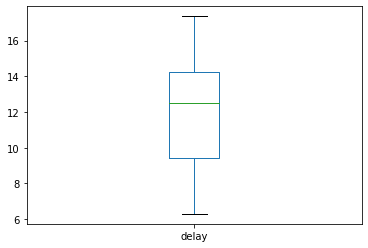

In [30]:
log.write("Plotting delay list ...")

print(transition_data_letters["delay"].mean())
transition_data_letters["delay"].plot.box()

In [12]:
log.write("Creating complete data set for deep learning ...\n")
data_arr = []

#for input_transition in input_transition_list:
#    log.write(str(input_transition)+"\n")
#log.write("\n")

for i in range(0, len(input_transition_list)):
    test_case = []
    for j in range(0, input_num):
        volt_initial = 0; volt_final = 0; dt = 0;
        if (input_transition_list[i][2*j] == "0"):
            volt_initial = 0;
            volt_final = 0;
        elif (input_transition_list[i][2*j] == "1"):
            volt_initial = VHIGH;
            volt_final = VHIGH;
        elif (input_transition_list[i][2*j] == "R"):
            volt_initial = 0;
            volt_final = VHIGH;
        elif (input_transition_list[i][2*j] == "F"):
            volt_initial = VHIGH;
            volt_final = 0;
        dt = input_transition_list[i][2*j+1]

        test_case.append(volt_initial);
        test_case.append(volt_final);
        test_case.append(dt)

    data_arr.append(test_case)

#for input_transition in data_arr:
#    log.write(str(input_transition)+"\n")
#log.write("\n")

log.write("Making pandas dataframes ...\n")

column_hierarchy = pd.MultiIndex.from_product([[i for i in range(1, input_num+1)], ["V_i", "V_f", "dt"]])
log.write(str(column_hierarchy)+"\n")

transition_data = pd.DataFrame(data_arr, columns=column_hierarchy)

transition_data["delay"] = delay_arr
transition_data["runtime"] = runtime_arr
print("Done")
transition_data

Done


1               2                delay runtime
    V_i  V_f    dt  V_i  V_f    dt                  
0   1.5  1.5  10.0  0.0  1.5  10.0  12.59510   0.130
1   1.5  1.5  20.0  0.0  1.5  20.0  12.95500   0.020
2   1.5  1.5  30.0  0.0  1.5  30.0  13.46440   0.016
3   1.5  1.5  10.0  1.5  0.0  10.0  13.52990   0.016
4   1.5  1.5  20.0  1.5  0.0  20.0  15.30400   0.016
5   1.5  1.5  30.0  1.5  0.0  30.0  17.36090   0.021
6   0.0  1.5  10.0  1.5  1.5  10.0   9.16758   0.023
7   0.0  1.5  20.0  1.5  1.5  20.0  10.16490   0.017
8   0.0  1.5  30.0  1.5  1.5  30.0  10.66270   0.020
9   0.0  1.5  10.0  0.0  1.5  10.0  14.45810   0.021
10  0.0  1.5  20.0  0.0  1.5  20.0  15.71280   0.027
11  0.0  1.5  30.0  0.0  1.5  30.0  17.27230   0.020
12  1.5  0.0  10.0  1.5  1.5  10.0   8.65349   0.017
13  1.5  0.0  20.0  1.5  1.5  20.0  10.70130   0.020
14  1.5  0.0  30.0  1.5  1.5  30.0  12.42250   0.015
15  1.5  0.0  10.0  1.5  0.0  10.0   6.28928   0.016
16  1.5  0.0  20.0  1.5  0.0  20.0   8.01101   0.015
17  1.5  0.0  30.0  1.5  0.0  30.0   8.52725   0.021

In [21]:
log.write("Making train / test split ...\n")

from sklearn.model_selection import train_test_split

random_pick = True

test_fraction = 0.75
transitions_letters_train, transitions_letters_test, transition_data_train, transition_data_test = \
            train_test_split(transition_data_letters, transition_data ,test_size=test_fraction)
    
I_train = transition_data_train[[i for i in range(1, input_num+1)]].values
O_train = transition_data_train["delay"].values
I_test = transition_data_test[[i for i in range(1, input_num+1)]].values
O_test = transition_data_test["delay"].values
print("Done")
transition_data_train

Done


1               2                delay runtime
    V_i  V_f    dt  V_i  V_f    dt                  
10  0.0  1.5  20.0  0.0  1.5  20.0  15.71280   0.027
8   0.0  1.5  30.0  1.5  1.5  30.0  10.66270   0.020
12  1.5  0.0  10.0  1.5  1.5  10.0   8.65349   0.017
7   0.0  1.5  20.0  1.5  1.5  20.0  10.16490   0.017

In [22]:
log.write("Scaling train data set for DNN ...\n")

from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
normalizer.fit(I_train)
I_train_scaled = normalizer.transform(I_train)
I_test_scaled = normalizer.transform(I_test)
print("Done")

Done


In [23]:
log.write("Initializing results directory ...\n")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

dnn_struct_dir = "DNN-results-T1-"
dnn_struct_dir += str(int(100*(1-test_fraction)))

# print(dnn_struct_dir)

super_dir = dnn_struct_dir+"/"+str(input_num)
if random_pick:
    super_dir += "/randomized"

#struct_file = open(super_dir+"/test.dnn", "r")
#structures_str = struct_file.readlines()
#struct_file.close()

#dnn_structures = [[int(num) for num in line[0:-1].split()] for line in structures_str]

import matplotlib.pyplot as plt
import math

test_dir = super_dir+"/"+gate_name



if os.path.exists(test_dir) == False:
    os.makedirs(test_dir)

#structure = dnn_structures[3]
#structure = [30, 30]
structure = []
for i in range(0, math.floor(math.sqrt(input_num))):
    structure.append(math.floor(6*input_num))

print(structure)

struct_name = str(structure[0])
for n in structure[1:]:
    struct_name += "-"+str(n)
fname = test_dir+"/"+struct_name+"_"
print(fname)

in_letters_train = transitions_letters_train.values
in_letters_test = transitions_letters_test.values

print("Done")    

#if os.path.exists(fname+"_1.out"):
#    continue

DNN-results-T1-25
[12]
DNN-results-T1-25/2/randomized/NAND/12_
Done


In [20]:
import math
log.write("Run DNN training and prediction ...\n")

time_naive = transition_data["runtime"].sum()
time_new = transition_data_train["runtime"].sum()

print(time_naive)
print(time_new)
print()

# borrowed from https://stackoverflow.com/questions/57181551/can-i-write-a-keras-callback-that-records-and-returns-the-total-training-time
#--------------------------------------------------
from timeit import default_timer as timer
class TimingCallback(tf.keras.callbacks.Callback):
    def __init__(self, logs={}):
        self.trainlogs=[]
        self.predictlogs=[]
    def on_epoch_begin(self, epoch, logs={}):
        self.epochstarttime = timer()
    def on_epoch_end(self, epoch, logs={}):
        self.trainlogs.append(timer()-self.epochstarttime)
    def on_predict_batch_begin(self, batch, logs={}):
        self.batchstarttime = timer()
    def on_predict_batch_end(self, batch, logs={}):
        self.predictlogs.append(timer()-self.batchstarttime)
#--------------------------------------------------

avg_loss_test = 0
avg_time_ML = 0

# added 3/2/22
m_test = 0
m_cum = 0
ms_errors = 0
ms_errorscum = 0
rms_errors = 0
rms_errorscum = 0
nrms_errors = 0
nrms_errorscum = 0

# 3 time variables: time_compile, time_train, time_predict

num_epochs = 1500

for i in range(1, 3+1): # 3 trials per DNN structure
    print("Trial "+str(i))
    
    model = Sequential()
    for n in structure:
        model.add(Dense(n, kernel_initializer='normal', activation='relu'))
    model.add(Dense(1)) # output node
    
    log.write("Training deep learning model with structure " + struct_name + " ...\n")
    
    # make a new callback object
    tcb = TimingCallback()
    
    compile_start = timer()
    model.compile(optimizer='rmsprop',loss='mse')
    time_compile = timer() - compile_start

    model.fit(I_train_scaled, O_train, epochs=num_epochs, verbose=0, callbacks=[tcb])
    time_train = sum(tcb.trainlogs)
        
    losses = pd.DataFrame(model.history.history)
    loss_train = losses.iloc[num_epochs-1].values[0]
    print("train: " + str(loss_train))
        
    loss_test = model.evaluate(I_test_scaled, O_test, verbose=0)
    print("test: " + str(loss_test))
    avg_loss_test += loss_test # add to average loss
    
    # output loss curve over time for training
    plt.plot(losses)
    plt.savefig(fname+"_"+str(i)+"_train_loss.png")
    plt.close()
        
    log.write("Finding inputs that caused a large deviation from actual output ...\n")
    # train data
    # plot actual vs prediction
    predictions_train = model.predict(I_train_scaled).flatten()
    plt.scatter(O_train, predictions_train)
    plt.plot(O_train, O_train,'r')
    plt.savefig(fname+"_"+str(i)+"_train.png")
    plt.close()
    # find outliers in train data
    errors = (predictions_train - O_train)**2
    errors_scaled = errors / np.amax(errors)
    which_outliers_train = (errors_scaled > 0.5) & (errors > 144)
        
    # test data
    # plot actual vs prediction
    predictions_test = model.predict(I_test_scaled, callbacks=[tcb]).flatten()
    plt.scatter(O_test, predictions_test)
    plt.plot(O_test, O_test,'r')
    plt.savefig(fname+"_"+str(i)+"_test.png")
    plt.close()
    # find outliers in test data
    errors = (predictions_test - O_test)**2
    errors_scaled = errors / np.amax(errors)
    which_outliers_test = (errors_scaled > 0.5) & (errors > 144)
    
    # added 3/2/22
    m_test = np.mean(O_test)
    m_cum = m_test + m_cum
    ms_errors = np.mean(errors)
    ms_errorscum = ms_errors + ms_errorscum
    # print("Length:", np.ndim(errors))
    rms_errors = math.sqrt(ms_errors)
    rms_errorscum = rms_errors + rms_errorscum
    nrms_errors = rms_errors / m_test
    nrms_errorscum = nrms_errors + nrms_errorscum
    
    # get the time taken for predicting test set
    time_predict = sum(tcb.predictlogs)
    
    print("Compile time:", time_compile)
    print("Train time:", time_train)
    print("Predict time:", time_predict)
    
    
    struct_out = open(fname+"_"+str(i)+".out", "w")
    
    struct_out.write("Compile time: "+str(time_compile)+"\n")
    struct_out.write("Train time: "+str(time_train)+"\n")
    struct_out.write("Predict time: "+str(time_predict)+"\n")
    struct_out.write("Training set simulation time: "+str(time_new)+"\n")
    struct_out.write("Total time: "+str(time_new+time_compile+time_train+time_predict)+"\n")
    
    
    struct_out.write("Train loss: " + str(loss_train) + "\n")
    outliers_train = in_letters_train[which_outliers_train]
    outliers_delay_train = predictions_train[which_outliers_train]
    print(outliers_train)
    for i in range(0, outliers_train.shape[0]):
        for j in range(0, 2*input_num+1):
            struct_out.write(str(outliers_train[i][j]) + " ")
        struct_out.write(str(outliers_delay_train[i]))
        struct_out.write("\n")
    
    struct_out.write("Test loss: " + str(loss_test) + "\n")
    outliers_test = in_letters_test[which_outliers_test]
    outliers_delay_test = predictions_test[which_outliers_test]
    print(outliers_test)
    for i in range(0, outliers_test.shape[0]):
        for j in range(0, 2*input_num+1):
            struct_out.write(str(outliers_test[i][j]) + " ")
        struct_out.write(str(outliers_delay_test[i]))
        struct_out.write("\n")
    
    struct_out.write("Mean of test: "+str(m_test)+"\n")
    struct_out.write("MSE: "+str(ms_errors)+"\n")
    struct_out.write("RMSE: "+str(rms_errors)+"\n")
    struct_out.write("NRMSE: "+str(nrms_errors)+"\n")
    
    struct_out.close()
    
    avg_time_ML += time_compile + time_train + time_predict # add to average cumulative time spent on ML
    
    print()
    
    
# added 3/2/22
m_cum /= 3
ms_errorscum /= 3 
rms_errorscum /= 3
nrms_errorscum /= 3

avg_loss_test /= 3
avg_time_ML /= 3

print("Avg loss:", avg_loss_test)
print("Avg externally calculated mean of test set:", m_cum)
print("Avg externally calculated mse:", ms_errorscum)
print("Avg externally calculated rmse:", rms_errorscum)
print("Avg externally calculated nrmse:", nrms_errorscum)
print("Avg time for ML:", avg_time_ML)

time_new += avg_time_ML

print("Naive:", time_naive)
print("New:", time_new)

#-------------------------------------------
from datetime import datetime

t_now = datetime.now()
exact_time = t_now.strftime("%Y-%m-%d_%H-%M-%S")
print(exact_time)
times_out = open(fname+exact_time+"_summary.txt", "w")

# output the time taken (by each approach) for finding the delays for all input transition combinations
times_out.write("Time for naive approach: "+str(time_naive)+" sec\n")
times_out.write("Average time for ML approach: "+str(time_new)+" sec\n")
times_out.write("Average error (MSE) for ML approach: "+str(avg_loss_test)+"\n")
times_out.write("Calculated Mean of test set: "+str(m_cum)+"\n")
times_out.write("Calculated MSE: "+str(ms_errorscum)+"\n")
times_out.write("Calculated RMSE: "+str(rms_errorscum)+"\n")
times_out.write("Calculated NRMSE: "+str(nrms_errorscum)+"\n")

times_out.close()


0.45100000000000007
0.18300000000000002

Trial 1
train: 0.0007454304723069072
test: 38.28548049926758
Compile time: 0.015309762999550003
Train time: 2.3690699429985216
Predict time: 0.0011757530000977567
[]
[]

Trial 2
train: 0.0005568559281527996
test: 35.60261917114258
Compile time: 0.003909948999989865
Train time: 2.2353783800117526
Predict time: 0.001081383999917307
[]
[]

Trial 3
train: 0.0005973802180960774
test: 34.744834899902344
Compile time: 0.0033463089998804207
Train time: 2.278560115007622
Predict time: 0.0010447919999023725
[]
[]

Avg loss: 36.210978190104164
Avg externally calculated mean of test set: 12.168957857142855
Avg externally calculated mse: 36.21097348635237
Avg externally calculated rmse: 6.0162643416449475
Avg externally calculated nrmse: 0.49439437725668184
Avg time for ML: 2.3029587960057447
Naive: 0.45100000000000007
New: 2.4859587960057445
2022-03-05_22-05-43
